# Efficient Programming with Python/C++ interop

**SOLUTION**

In [1]:
%load_ext memory_profiler

Calling into C or C++ functions from Python is fundamental for binding to existing libraries, and for running your most expensive computations without any Python overhead.

In this tutorial, we'll show a few ways to do Python/C++ interoperability in your HPC project:

  * Basic C library calls with **ctypes** and **cffi**
  * Generate bindings to C++ code with **nanobind**
  * Use C++ dynamically from Python with automatic bindings provided by **cppjit**

## Calling basic functions with **ctypes**

[ctypes](https://docs.python.org/3.14/library/ctypes.html) is a builtin Python module for foreign function calling:
* Zero dependencies
* Shared libraries with C interfaces only
* No help with creating/managing the SO's.

#### Example 1:

In [2]:
%%writefile simple.c

float square(float x) {
    return x*x;
}

Writing simple.c


Compile this to a shared library that Python knows how to use with `ctypes`:

In [3]:
!gcc -shared -fPIC -o simple.so simple.c

#### Desired usage in Python:

```python
y = square(x)
```

In [4]:
import ctypes

lib = ctypes.cdll.LoadLibrary("./simple.so")

> Warning: You can only load a file once; future loads just reuse the existing library (much like Python imports). So if you change the file, you need to restart the kernel.

Now, we need to set the argument types - they can't be inferred from an SO.

In [5]:
lib.square.argtypes = (ctypes.c_float,)
lib.square.restype = ctypes.c_float

In [6]:
%%timeit
lib.square(2.5)

134 ns ± 0.788 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


Doing the same with Python directly:

In [7]:
def mul(a):
    return a*a

In [8]:
%%timeit
mul(2.5)

25.3 ns ± 0.164 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


*Question: why is using just Python faster in this case?*

What were the steps taken?

1. Load the library, by passing the `.so` file to the ctypes library loader.
1. Set the expected arg types and return type for the function call. We had to use the types from ctypes since compiled types are not the same as Python types. SO's do not store signatures!

There is an alternate way to do this:

1. Create a new C Function type, listing the return type, then the argument type(s) if there are any. Yes, this is different order and structure than Type Hinting in modern Python...

In [9]:
float_float_t = ctypes.CFUNCTYPE(ctypes.c_float, ctypes.c_float)

Now "cast" the function with your function type.

In [10]:
squarefunc = float_float_t(lib.square)

And this also works:

In [11]:
%%timeit
squarefunc(2.0)

325 ns ± 1.32 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


However, it sets up a *little* bit of extra machinery so it's a hair slower. However, this is itself now a valid c_type and can be passed to code! You can even wrap Python functions (won't be faster, but powerful, nevertheless)!

Suggestion: wrap your library in a class!

In [12]:
class SimpleLib:
    def __init__(self, file_to_load: str):
        self._lib = ctypes.cdll.LoadLibrary(file_to_load)
        self._lib.square.argtypes = (ctypes.c_float,)
        self._lib.square.restype = ctypes.c_float

    def square(self, x: float) -> float:
        return self._lib.square(x)
    
    #... N

In [13]:
simple = SimpleLib("./simple.so")
simple.square(2)

4.0

In practice, you will usually have a Python wrapper module (not just a class) to "pythonize" the interface to the shared library.

### But what about C++ (and all other languages)?

This wasn't really language specific, it is just a property of compiled libraries. However, C++ (and possibly other libraries) do not by default provide a nice exported interface. In C++, because of features like overloading, the names are "mangled" in a compiler specific way. But you can manually export a nice interface:

 Let's try a slightly more advanced example, this time in C++:

In [14]:
%%writefile templates.cpp


template<class T>
T square(T x) {
    return x*x;
}


extern "C" {
    int square_int(int x) {
        return square<int>(x);
    }
    
    double square_double(double x) {
        return square<double>(x);
    }
}

Writing templates.cpp


This is not Python specific! If you want to load a shared object (DLL on Windows) from any language, you need to do this:

In [15]:
!g++ templates.cpp -shared -fPIC -o templates.so

In [16]:
from functools import singledispatchmethod


class TemplateLib(object):
    def __init__(self, file_to_load: str):
        self._lib = ctypes.cdll.LoadLibrary(file_to_load)

        self._lib.square_double.argtypes = (ctypes.c_double,)
        self._lib.square_double.restype = ctypes.c_double

        self._lib.square_int.argtypes = (ctypes.c_int,)
        self._lib.square_int.restype = ctypes.c_int

    @singledispatchmethod
    def square(self, arg):
        raise NotImplementedError("Not a registered type")

    @square.register
    def _(self, x: int):
        return self._lib.square_int(x)

    @square.register
    def _(self, x: float):
        return self._lib.square_double(x)

In [17]:
templates = TemplateLib("./templates.so")

In [18]:
templates.square(2)

4

In [19]:
templates.square(2.0)

4.0

## NumPy tools

Let's briefly mention NumPy has adapters to help you with ctypes, called [numpy.ctypeslib](https://numpy.org/doc/stable/reference/routines.ctypeslib.html?highlight=ctypeslib#module-numpy.ctypeslib). You can convert to/from *any* object providing an `__array_interface__`, like NumPy arrays. It has a loader with more consistent defaults across operating systems. You also have a special pointer that can do bounds checking and such for array arguments.

## Alternative for foreign function calling - **cffi**

The [CFFI](http://cffi.readthedocs.io/en/latest/overview.html) module is an alternative to the builtin **ctypes** that requires less boilerplate code.

* The *C Foreign Function Interface* for Python
* C only
* Developed for PyPy, but available in CPython too

The same example as before:

In [20]:
from cffi import FFI

ffi = FFI()

ffi.cdef("float square(float);")

C = ffi.dlopen("./simple.so")

C.square(2.0)

4.0

In [21]:
C.square

<cdata 'float(*)(float)' 0x710a0c0370f9>

Notice we were able to give a C header this time and it's not necessary to bookkeep the C function types by hand.

### Exercise 1- Try it yourself

Let's try it now. We'll take a few minutes to play with the code; we are also available to help with troubleshooting at this time. Square the elements in this array (for simplicity, do it in-place):

In [22]:
%%writefile array_square.c

void squares(float* arr, int size) {
    for(int i=0; i<size; i++)
        arr[i] = arr[i]*arr[i];
}

Writing array_square.c


In [23]:
!gcc array_square.c -shared -fPIC -o array_square.so

In [24]:
import numpy as np
import ctypes

alib = ctypes.cdll.LoadLibrary("./array_square.so")

In [25]:
arr = np.array([1, 2, 3, 4, 5], dtype=np.float32)

In [26]:
# Write your solution here!
#
# It should include two steps:
#   * annotate the right `argtype` and `restype` to the squares function
#   * call the squares function with the numpy array
#
# Bonus points if you manage to use the right types that allow you pass
# the NumPy array directly without converting it to a builtin ctypes type.

In [27]:
alib.squares.argtypes = (ctypes.POINTER(ctypes.c_float), ctypes.c_int)
alib.squares.restype = None

alib.squares(np.ctypeslib.as_ctypes(arr), arr.size)

alib.squares.argtypes = (np.ctypeslib.ndpointer(dtype=np.float32, ndim=1), ctypes.c_int)
alib.squares.restype = None

alib.squares(arr, len(arr))

In [28]:
print(arr * arr) # This should be [ 1.  4.  9. 16. 25.]

[1.00000e+00 2.56000e+02 6.56100e+03 6.55360e+04 3.90625e+05]


## Using libraries to generate bindings - **nanobind**

**[nanobind](https://github.com/wjakob/nanobind)** is a modern evolution of the `Boost.Python` and `pybind11` libraries, giving you the tools to build Python modules that provide bindings for your C/C++ library.

### Basic example

Setting up to write and compile nanobind extensions:

In [29]:
import nanobind
import os
import sys

from nanobind import include_dir, source_dir

Find the nanobind include directory and the extra pieces a manual build needs.

Unlike pybind11, **nanobind is not header-only** — it ships a small library (`nb_combined.cpp`) that must be compiled into the extension. It also bundles its `tsl::robin_map` dependency, whose headers live alongside the package. We collect:

- `nbinc`  — nanobind's own include directory
- `robin`  — the bundled `robin_map` include directory
- `nbsrc`  — the nanobind library source to compile in
- `plat`   — platform-specific linker flag
- `pyinc`  — Python's compile flags"

In [30]:
nbinc = "-I " + include_dir()
robin = "-I " + os.path.join(os.path.dirname(nanobind.__file__), "ext", "robin_map", "include")
nbsrc = os.path.join(source_dir(), "nb_combined.cpp")
plat  = "-undefined dynamic_lookup" if "darwin" in sys.platform else "-fPIC"
pyinc = !python3-config --cflags

print(f"{nbinc = }")
print(f"{robin = }")
print(f"{nbsrc = }")
print(f"{plat  = }")
print(f"{pyinc.s = }")

nbinc = '-I /usr/local/lib/python3.12/dist-packages/nanobind/include'
robin = '-I /usr/local/lib/python3.12/dist-packages/nanobind/ext/robin_map/include'
nbsrc = '/usr/local/lib/python3.12/dist-packages/nanobind/src/nb_combined.cpp'
plat  = '-fPIC'
pyinc.s = '-I/usr/include/python3.12 -I/usr/include/python3.12  -fno-strict-overflow -Wsign-compare -g       -fstack-protector-strong -Wformat -Werror=format-security  -DNDEBUG -g -O2 -Wall'


A simple example:

In [31]:
%%writefile pysimple.cpp

#include <nanobind/nanobind.h>

namespace nb = nanobind;

float square(float x) {
    return x*x;
}

NB_MODULE(pysimple, m) {
    m.def("square", &square);
}

Writing pysimple.cpp


Compile, import and run. Note that **nanobind requires C++17** (pybind11 only needed C++11), and we compile `{nbsrc}` into the module:

In [32]:
!c++ -std=c++17 pysimple.cpp {nbsrc} -shared {nbinc} {robin} {pyinc.s} -o pysimple.so {plat}

As simple as compile, import and run

In [33]:
import pysimple

pysimple.square(3)

9.0

nanobind also allows using templated functions:

In [34]:
%%writefile pytempl.cpp

#include <nanobind/nanobind.h>

namespace nb = nanobind;

template<class T>
T add(T x) {
    return x+x;
}

NB_MODULE(pytempl, m) {
    m.def("add", [](int value)    { return add(value); });
    m.def("add", [](double value) { return add(value); });
}

Writing pytempl.cpp


Note: Requires registering one binding per Python entry type; the rest is handled by C++.

In [35]:
!c++ pytempl.cpp -std=c++17 {nbsrc} -shared {nbinc} {robin} {pyinc.s} -o pytempl.so {plat}

In [36]:
import pytempl

pytempl.add(3)

6

In [37]:
pytempl.add(3.0)

6.0

For production builds you would normally let CMake (via nanobind's `nanobind_add_module`) handle this, and add size/robustness flags such as `-Os -fvisibility=hidden -flto` plus stripping. The manual command above is kept minimal for the purpose of this tutorial.

### nanobind example with classes

In [38]:
import nanobind
import os
import sys

from nanobind import include_dir, source_dir

What about classes?

In [39]:
%%writefile VectorClass.hpp
#pragma once

class Vector2D {
    double x;
    double y;

public:

    Vector2D(double x, double y): x(x), y(y) {}

    double get_x() const {
        return x;
    }

    double get_y() const {
        return y;
    }

    void set_x(double val) {
        x = val;
    }

    void set_y(double val) {
        y = val;
    }


    Vector2D& operator+= (const Vector2D& other) {
        x += other.x;
        y += other.y;
        return *this;
    }

    Vector2D operator+ (const Vector2D& other) const {
        return Vector2D(x + other.x, y + other.y);
    }
};

Writing VectorClass.hpp


Our binding code shows a couple more features:

In [40]:
%%writefile vectorclass.cpp

#include <nanobind/nanobind.h>
#include <nanobind/operators.h>
#include "VectorClass.hpp"

namespace nb = nanobind;
using namespace nanobind::literals;

NB_MODULE(vectorclass, m) {
    nb::class_<Vector2D>(m, "Vector2D")
        .def(nb::init<double, double>(), "x"_a, "y"_a)
        .def_prop_rw("x", &Vector2D::get_x, &Vector2D::set_x)
        .def_prop_rw("y", &Vector2D::get_y, &Vector2D::set_y)
        .def(nb::self += nb::self)
        .def(nb::self + nb::self)
        .def("__repr__", [](nb::object self){
            return nb::str("{0.__class__.__name__}({0.x}, {0.y})").format(self);
        })
    ;
}

Writing vectorclass.cpp


In [41]:
!c++ -std=c++17 vectorclass.cpp {nbsrc} -shared {nbinc} {robin} {pyinc.s} -o vectorclass.so {plat}

In [42]:
import vectorclass

v = vectorclass.Vector2D(1, 2)
print(f"{v.x = }, {v.y = }")

v.x = 1.0, v.y = 2.0


### Exercise 2 - NumPy arrays and nanobind

Write `scale(arr, factor)` that multiplies a 1-D float64 NumPy array in place, using a plain C++ core function `void scale(double*, size_t, double)`. Bind it with `nb::ndarray` so the NumPy array is modified without copying.

In [43]:
%%writefile nanobind_numpy.cpp

#include <nanobind/nanobind.h>
#include <nanobind/ndarray.h>
namespace nb = nanobind;
using namespace nanobind::literals;

void scale(double* data, size_t n, double factor) {
    for (size_t i = 0; i < n; ++i) data[i] *= factor;   // the "C-style" core
}

NB_MODULE(nanobind_numpy, m) {
    m.def("scale",
        [](nb::ndarray<double, nb::ndim<1>, nb::c_contig, nb::device::cpu> arr, double factor) {
            scale(arr.data(), arr.shape(0), factor);
        }, "arr"_a, "factor"_a);
}

Writing nanobind_numpy.cpp


In [44]:
!c++ -std=c++17 nanobind_numpy.cpp {nbsrc} -shared {nbinc} {robin} {pyinc.s} -o nanobind_numpy.so {plat}

In [45]:
import nanobind_numpy
import numpy as np

# What happens if this would be dtype=np.int32 ?
# Can you ensure that the behavior is still sensible in this case?
a = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float64)

# nanobind_numpy.scale(a, 10.0) # comment this out to try the code
print(a)   # [10. 20. 30. 40.]  -- original mutated, no copy

[1. 2. 3. 4.]


## Automatic bindings with **cppjit**

cppjit combines the convenience of the Python language with the efficiency of C++ implementations. The dynamic C++ bindings are powered by the C++ interpreter Cling, allowing you to conveniently use efficient C++ implementations from Python.

In [46]:
import cppjit
import numpy as np

Just-in-time compilation of C++ functions

In [47]:
cppjit.cppdef('''

float smallest_diff(float* v1, float* v2, std::size_t size) {
    float min_diff = std::numeric_limits<float>::max();
    for (std::size_t i1 = 0; i1 < size; i1++) {
        for (std::size_t i2 = 0; i2 < size; i2++) {
            float diff = std::abs(v1[i1] - v2[i2]);
            if (diff < min_diff) {
                min_diff = diff;
            }
        }
    }
    return min_diff;
}
''');

As example inputs, we generate two numpy arrays with random numbers.

In [48]:
size = 100
v1 = np.random.randn(size).astype(np.float32)
v2 = np.random.randn(size).astype(np.float32)

Use the function directly: cppjit **seamlessly integrates with NumPy arrays!**

In [49]:
%%timeit
cppjit.gbl.smallest_diff(v1, v2, size)

17.7 μs ± 24.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


How does the C++ kernel compare to a pure Python implementation?

In [50]:
def smallest_diff(x1, x2):
    min_diff = float('inf')
    for e1 in x1:
        for e2 in x2:
            diff = abs(e1 - e2)
            if diff < min_diff:
                min_diff = diff
    return min_diff

**The Python implementation is roughly a factor of 40 slower!**

In [51]:
%%timeit
smallest_diff(v1, v2)

771 μs ± 9.84 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Loading of precompiled functions

Improved C++ performance can be expected by precompiling the functionality and loading the library into cppjit 

In [52]:
%%writefile diff_small.hxx

#include <cstddef>
#include <limits>
#include <cmath> 
float optimized_smallest_diff(float* v1, float* v2, std::size_t size);

Writing diff_small.hxx


In [53]:
%%writefile diff_small.cxx

# include "diff_small.hxx"

float optimized_smallest_diff(float* v1, float* v2, std::size_t size) {
    float min_diff = std::numeric_limits<float>::max();
    for (std::size_t i1 = 0; i1 < size; i1++) {
        for (std::size_t i2 = 0; i2 < size; i2++) {
            float diff = std::abs(v1[i1] - v2[i2]);
            if (diff < min_diff) {
                min_diff = diff;
            }
        }
    }
    return min_diff;
}


Writing diff_small.cxx


In [54]:
!g++ -Ofast -shared -fPIC -o libanalysis.so diff_small.cxx

You can interactively include the header and functionality from the shared library.

In [55]:
cppjit.cppdef('#include "diff_small.hxx"')
cppjit.load_library('libanalysis.so')

True

In [56]:
cppjit.gbl.__dict__

mappingproxy({'__module__': 'cppjit.cppyy._cpython_cppyy',
              '__dict__': <attribute '__dict__' of '' objects>,
              '__weakref__': <attribute '__weakref__' of '' objects>,
              '__doc__': None,
              '__init__': <cppyy.CPPOverload at 0x7109b8fc6980>,
              'std': <namespace cppyy.gbl.std at 0x35828ff0>,
              'Dispatch': <namespace cppyy.gbl.CppInternal.Dispatch at 0x35bc8180>,
              'cling': <namespace cppyy.gbl.cling at 0x3c613ee0>,
              'int8_t': cppyy.gbl.int8_t,
              'uint8_t': cppyy.gbl.uint8_t,
              'smallest_diff': <cppyy.CPPOverload at 0x7109b8f333c0>})

**The loaded library improves the runtime further!**

While this may not make a huge difference for small files like this example, large files benefit since your code is recompiled every time you `cppdef`

In [57]:
%%timeit

cppjit.gbl.optimized_smallest_diff(v1, v2, size)

1.4 μs ± 1.69 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [58]:
cppjit.gbl.__dict__

mappingproxy({'__module__': 'cppjit.cppyy._cpython_cppyy',
              '__dict__': <attribute '__dict__' of '' objects>,
              '__weakref__': <attribute '__weakref__' of '' objects>,
              '__doc__': None,
              '__init__': <cppyy.CPPOverload at 0x7109b8fc6980>,
              'std': <namespace cppyy.gbl.std at 0x35828ff0>,
              'Dispatch': <namespace cppyy.gbl.CppInternal.Dispatch at 0x35bc8180>,
              'cling': <namespace cppyy.gbl.cling at 0x3c613ee0>,
              'int8_t': cppyy.gbl.int8_t,
              'uint8_t': cppyy.gbl.uint8_t,
              'smallest_diff': <cppyy.CPPOverload at 0x7109b8f333c0>,
              'optimized_smallest_diff': <cppyy.CPPOverload at 0x7109b8fb9400>})

Finally, we can show that all implementations come to the same result:

In [59]:
print('cppjit:', cppjit.gbl.smallest_diff(v1, v2, size))
print('Native Python:', smallest_diff(v1, v2))
print('cppjit (loaded):', cppjit.gbl.optimized_smallest_diff(v1, v2, size))

cppjit: 1.4960765838623047e-05
Native Python: 1.4960766e-05
cppjit (loaded): 1.4960765838623047e-05


### Let's look at examples of runtime features in cppjit

We can easily do template instantiations *at runtime* with cppjit.

In [60]:
cppjit.cppdef('''template<class T>
T add(T x) {
    return x+x;
}''')

True

We can automatically call `cppjit.gbl.add` now!

In [61]:
cppjit.gbl.add(3)

6

In [62]:
cppjit.gbl.add(3.0)

6.0

In [63]:
cppjit.gbl.add('a')

b'aa'

More Runtime Template Instantiations:

In [64]:
cppjit.cppdef('''
struct MyClass {
    MyClass(int i) : fData(i) {}
    virtual ~MyClass() {}
    virtual int add(int i) {
        return fData + i;
    }
    int fData;
};''')

True

Creating a std::vector of the C++ class

In [65]:
v = cppjit.gbl.std.vector[cppjit.gbl.MyClass]()
v

<cppyy.gbl.std.vector<MyClass, std::allocator<MyClass>> object at 0x3c8cb3d0>

In [66]:
for i in range(10):
    v.emplace_back(i)

In [67]:
len(v)

10

In [68]:
for m in v:
    print(m.fData, end = ' ')

0 1 2 3 4 5 6 7 8 9 

Runtime Callbacks

In [69]:
cppjit.cppdef('''
typedef std::function<int(int)> F;
int callFun(const F& f, int i) {
    return f(i);
}
''')

True

### Exercise 3 - Using callbacks to Python

The runtime callback mechanism is one of the most powerful features of cppjit, as it can be used for example to call back into Python ML inference from C++.

Can you write a little example of how `callFun` can be called with a Python callable as the first argument?

In [70]:
# Write your code here

In [71]:
cppjit.gbl.callFun(lambda x: x + x, 2)

4

## Putting it all together: A final overview

Finally, we are comparing the different C/C++ interop approaches that were presented on a single compute-heavy example, and also compare it with NumPy.

Array-oriented programming (e.g. NumPy) connects Python with compiled code, but it's not the only way to do that (like the bindings we previously explored).

Although much faster than pure Python, array-oriented techniques are not as fast as imperative, compiled code.

In [72]:
%%writefile quadratic_formula_c.c

#include <math.h>

void run(double* a, double* b, double* c, double* output, int n_elems) {
    for (int i = 0;  i < n_elems;  i++) {
        output[i] = (-b[i] + sqrt(b[i]*b[i] - 4*a[i]*c[i])) / (2*a[i]);
    }
}


Writing quadratic_formula_c.c


In [73]:
!cc quadratic_formula_c.c -shared -fPIC -lm -o quadratic_formula_c.so

In [74]:
import ctypes
import numpy as np

quadratic_formula_c = ctypes.CDLL("./quadratic_formula_c.so")
quadratic_formula_c.run.argtypes = (ctypes.POINTER(ctypes.c_double),) * 4 + (ctypes.c_int, )
quadratic_formula_c.run.restype = None

In [75]:
n_elems = 1000000

In [76]:
a = np.random.uniform(5, 10, n_elems)
b = np.random.uniform(10, 20, n_elems)
c = np.random.uniform(-0.1, 0.1, n_elems)

In [77]:
output = np.zeros(n_elems, dtype=np.float64)
quadratic_formula_c.run(*[arg.ctypes.data_as(ctypes.POINTER(ctypes.c_double)) for arg in (a, b, c, output)], n_elems)
output

array([ 0.00270198,  0.00565826,  0.00148442, ...,  0.00167348,
       -0.00333326,  0.004366  ], shape=(1000000,))

In [78]:
ctypes_time = %timeit -o quadratic_formula_c.run(*[arg.ctypes.data_as(ctypes.POINTER(ctypes.c_double)) for arg in (a, b, c, output)], n_elems)

3.64 ms ± 6.57 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In Pure Python it would look like:

In [79]:
import math

def run(a, b, c):
    output = []
    for i in range(len(a)):
        output.append((-b[i] + math.sqrt(b[i]*b[i] - 4*a[i]*c[i])) / (2*a[i]))
    return output

In [80]:
py_time = %timeit -o run(a, b, c)

437 ms ± 1.94 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Let's look at memory:

In [81]:
%%memit

run(a, b, c)

peak memory: 407.75 MiB, increment: 28.12 MiB


NumPy is fast but not much better with memory. Measure memory usage first, so that we see the memory increment from NumPys initial allocation of working memory.

In [82]:
%%memit

output[:] = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

peak memory: 379.73 MiB, increment: 0.00 MiB


Why? NumPy allocates working memory for the intermediate steps.

* Memory allocation is expensive (`malloc` has to search for unused memory).
* Accessing different memory is expensive (the CPU can't re-use its cache, and acessing RAM is much slower than most mathematical operations).

*Note: the second time you run this cell you might not see memory increments, because NumPy re-uses pre-allocated working buffers.*

Now measure the time:

In [83]:
np_time = %timeit -o (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

4.26 ms ± 25.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Let's try nanobind now

Best way to make C++ extensions for Python: nanobind

In [84]:
%%writefile quadratic_formula_nanobind.cpp

#include <cmath>
#include <nanobind/nanobind.h>
#include <nanobind/ndarray.h>
namespace nb = nanobind;

void run(nb::ndarray<const double, nb::ndim<1>, nb::c_contig> a_numpy,
         nb::ndarray<const double, nb::ndim<1>, nb::c_contig> b_numpy,
         nb::ndarray<const double, nb::ndim<1>, nb::c_contig> c_numpy,
         nb::ndarray<double, nb::ndim<1>, nb::c_contig> output_numpy) {
    const double* a = a_numpy.data();
    const double* b = b_numpy.data();
    const double* c = c_numpy.data();
    double* output = output_numpy.data();
    for (size_t i = 0;  i < output_numpy.size();  i++) {
        output[i] = (-b[i] + std::sqrt(b[i]*b[i] - 4*a[i]*c[i])) / (2*a[i]);
    }
}

NB_MODULE(quadratic_formula_nanobind, m) {
    m.def("run", &run);
}

Writing quadratic_formula_nanobind.cpp


In [85]:
import os
import sys
import nanobind
from nanobind import include_dir, source_dir

inc = "-I " + include_dir()
robin = "-I " + os.path.join(os.path.dirname(nanobind.__file__), "ext", "robin_map", "include")
nbsrc = source_dir() + "/nb_combined.cpp"
plat = "-undefined dynamic_lookup" if "darwin" in sys.platform else "-fPIC"
pyinc = !python3-config --cflags

In [86]:
!c++ -std=c++17 quadratic_formula_nanobind.cpp {nbsrc} -shared {inc} {robin} {pyinc.s} -o quadratic_formula_nanobind.so {plat}

In [87]:
import quadratic_formula_nanobind

In [88]:
output = np.zeros(n_elems, dtype=np.float64)
quadratic_formula_nanobind.run(a, b, c, output)
output

array([ 0.00270198,  0.00565826,  0.00148442, ...,  0.00167348,
       -0.00333326,  0.004366  ], shape=(1000000,))

In [89]:
nanobind_time = %timeit -o quadratic_formula_nanobind.run(a, b, c, output)

2.84 ms ± 5.59 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Leaving Python, writing C++ code, and then importing it* is fine for a long-term project, like a library that will be used many times, but it's inconvenient in the middle of a data analysis.

*If we change the C++, recompile, and do

```python
import quadratic_formula_nanobind
```

again, we will _not_ get the new version. We would still have the old version, with no error messages or warnings!

### cppjit

In [90]:
import cppjit
cppjit.cppdef('''
#pragma cling optimize(3)
void run(double* a, double* b, double* c, double* output, int n_elems) {
    for (int i = 0;  i < n_elems;  i++) {
        output[i] = (-b[i] + sqrt(b[i]*b[i] - 4*a[i]*c[i])) / (2*a[i]);
    }
}
''')

True

In [91]:
# double * from NumPy
x = a.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
y = b.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
z = c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
cppjit_out = output.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

In [92]:
cppjit_time = %timeit -o cppjit.gbl.run(x, y, z, cppjit_out, n_elems)

3.95 ms ± 5.59 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [93]:
cppjit_mem = %memit -o cppjit.gbl.run(x, y, z, cppjit_out, n_elems)

peak memory: 382.83 MiB, increment: 0.00 MiB


In [94]:
cppjit_mem

<MemitResult : peak memory: 382.83 MiB, increment: 0.00 MiB>

In [95]:
# NumPy from double *
np.ctypeslib.as_array(cppjit_out, shape = (n_elems,))

array([ 0.00270198,  0.00565826,  0.00148442, ...,  0.00167348,
       -0.00333326,  0.004366  ], shape=(1000000,))

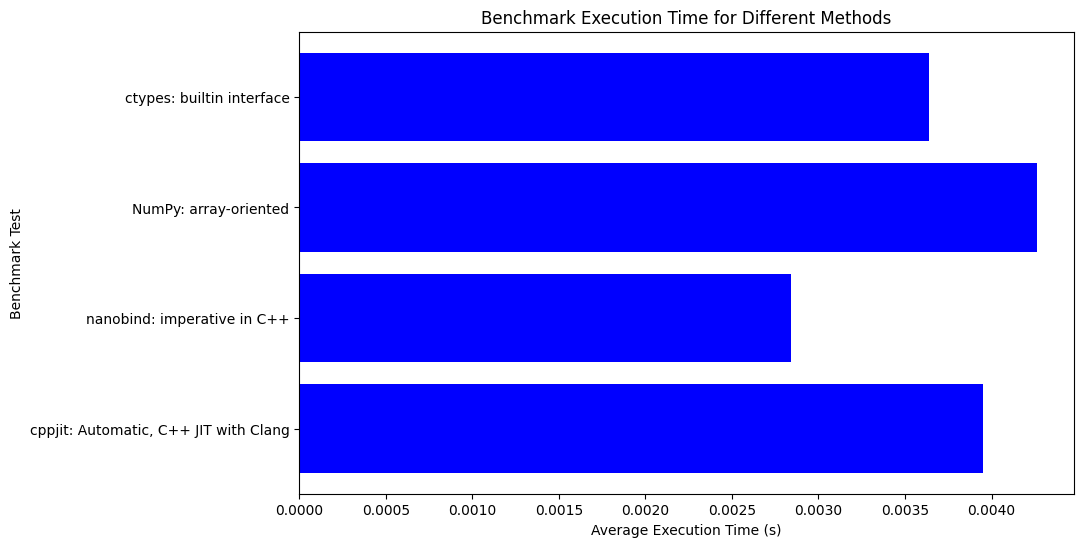

In [96]:
import matplotlib.pyplot as plt

def avg(lst): 
    return sum(lst.timings) / len(lst.timings) 

test_names = [
    #'Python "for" loops: imperative', # commented out because it's much slower anyway
    'ctypes: builtin interface',
    'NumPy: array-oriented',
    'nanobind: imperative in C++',
    "cppjit: Automatic, C++ JIT with Clang"
]
test_results = np.array([
    #avg(py_time),
    avg(ctypes_time),
    avg(np_time),
    avg(nanobind_time),
    avg(cppjit_time)
])

# Creating the plot
plt.figure(figsize=(10, 6))
plt.barh(test_names, test_results, color='blue')
plt.xlabel('Average Execution Time (s)')
plt.ylabel('Benchmark Test')
plt.title('Benchmark Execution Time for Different Methods')
plt.gca().invert_yaxis()  # Invert y-axis to have the fastest method at the top
plt.show()

### Exercise 4

Not all ways to interoperate with C/C++ code gave us the same runtime performance here. Where do the differences come from?